# Task 7.2: Provider(프로바이더) 이해 및 Job Monitoring(작업 모니터링)

이 노트북은 `Provider`, `Backend`, 그리고 `Job` 클래스를 포함하는 Qiskit Provider(프로바이더) 모델에 대한 실습 가이드를 제공합니다.

**목표(Goal):** 이러한 컴포넌트들이 어떻게 함께 작동하는지 이해하기 위해, 간단한 **Custom in-memory Backend(사용자 정의 인메모리 백엔드)** 를 구축해 보겠습니다. 해당 실습은 백엔드는 실제 양자 계산을 실행하지는 않지만 Qiskit 인터페이스를 올바르게 구현하여, Job(작업)을 제출하고 Result(결과)를 조회하는 전체 워크플로우를 확인할 수 있게 해줍니다.

## Objective 1: Provider, Backend, Job 추상 클래스

Qiskit Provider(프로바이더) 모델은 Qiskit이 다양한 실행 리소스(Backends)와 상호작용하는 방식을 보여줍니다.
*   **`Provider`:** 진입점입니다. 백엔드 그룹을 관리하고 접근 권한을 제공합니다 (예: `qiskit-ibm-provider`는 IBM의 백엔드에 대한 접근을 제공함).
*   **`BackendV2`:** 백엔드를 위한 현대적인 인터페이스입니다. 백엔드의 기능(`target`)을 설명하고 회로를 실행하기 위한 `.run()` 메서드를 가집니다.
*   **`Job`:** `backend.run()`에 의해 반환되는 객체입니다. 제출된 작업(Job)을 나타내며, 상태를 모니터링(`.status()`)하고 최종 결과(`.result()`)를 가져오는 데 사용됩니다.

### Step 1: Custom `Job`(사용자 정의 작업) 구현

Job(작업)의 수명 주기를 시뮬레이션하는 간단한 `MyJob` 클래스를 만드는 것부터 시작하겠습니다. 이 클래스는 실제 하드웨어를 실행하지는 않고 짧은 시간 동안 "RUNNING" 상태인 것처럼 동작한 결과를 보여줍니다.

In [1]:
import time
import uuid
from qiskit.providers import JobV1 as Job, JobStatus, JobError
from qiskit.result import Result

class MyJob(Job):
    """A simple, in-memory job class for demonstration."""
    def __init__(self, backend, job_id, circuit):
        super().__init__(backend, job_id)
        self._status = JobStatus.QUEUED
        self._circuit = circuit
        self._result = self._create_fake_result()
        print(f"-> Job {self._job_id} created for circuit '{self._circuit.name}'.")

    def _create_fake_result(self):
        """Creates a static, fake result object."""
        fake_counts = {'00': 512, '11': 512} # Simulate a perfect Bell state
        results_dict = {
            'backend_name': self._backend.name,
            'backend_version': self._backend.version,
            'job_id': self._job_id,
            'qobj_id': str(uuid.uuid4()),
            'success': True,
            'results': [
                {
                    'shots': 1024,
                    'success': True,
                    'header': {'name': self._circuit.name},
                    'data': {'counts': fake_counts}
                }
            ]
        }
        return Result.from_dict(results_dict)

    def submit(self):
        """Simulates submitting the job. It will move to RUNNING then DONE."""
        self._status = JobStatus.RUNNING
        print(f"-> Job {self._job_id} is now {self.status().name}.")
        # Simulate some execution time
        time.sleep(0.5)
        self._status = JobStatus.DONE
        print(f"-> Job {self._job_id} is now {self.status().name}.")

    def result(self):
        """Return the fake result."""
        if self._status is not JobStatus.DONE:
            raise JobError("Job has not completed yet.")
        return self._result

    def status(self):
        """Return the current job status."""
        return self._status

print("MyJob class defined successfully!")

MyJob class defined successfully!


### Step 2: Custom `BackendV2`(사용자 정의 백엔드) 구현

다음으로 `MyBackend`를 생성합니다. 이 클래스의 주요 역할은 기능(`target`)을 정의하고 `MyJob` 객체를 반환하는 `.run()` 메서드를 제공하는 것입니다.

**중요(Important):** `BackendV2`는 백엔드의 기본 옵션을 정의하는 `_default_options()` 메서드를 반드시 구현해야 합니다.

In [2]:
from qiskit.circuit import Measure, Reset, Parameter
from qiskit.circuit.library import SXGate, CXGate, UGate
from qiskit.providers import BackendV2, Options
from qiskit.transpiler import Target

class MyBackend(BackendV2):
    """A simple custom backend that returns our fake MyJob."""
    def __init__(self, provider=None):
        super().__init__(name="my_custom_backend", backend_version="1.0")
        self._provider = provider
        
        # --- Define the Backend's Target ---
        # The target describes exactly what gates and operations are supported.
        self._target = Target()
        theta = Parameter("theta")
        phi = Parameter("phi")
        lam = Parameter("lam")
        
        # Add supported instructions with their properties (on all qubits 0-4)
        self._target.add_instruction(UGate(theta, phi, lam), {(i,): None for i in range(5)})
        self._target.add_instruction(SXGate(), {(i,): None for i in range(5)})
        self._target.add_instruction(CXGate(), {(0, 1): None, (1, 2): None, (2, 3): None, (3, 4): None})
        self._target.add_instruction(Measure(), {(i,): None for i in range(5)})
        self._target.add_instruction(Reset(), {(i,): None for i in range(5)})
        
        print("-> MyBackend initialized.")

    @property
    def target(self):
        return self._target

    @property
    def max_circuits(self):
        return 1
    
    @classmethod
    def _default_options(cls):
        """Return default options for this backend."""
        return Options(shots=1024)

    def run(self, circuit, **kwargs):
        """'Run' a circuit by creating and submitting a MyJob instance."""
        job_id = str(uuid.uuid4())
        job = MyJob(backend=self, job_id=job_id, circuit=circuit)
        job.submit()
        return job

print("MyBackend class defined successfully!")

MyBackend class defined successfully!


### Step 3: Custom `Provider`(사용자 정의 프로바이더) 구현

마지막으로 `MyProvider` 클래스는 백엔드를 가져오기 위한 진입점 역할을 합니다. 더 이상 사용되지 않는(deprecated) 베이스 클래스를 상속받지 않고 간단한 프로바이더 클래스를 생성하겠습니다.

In [6]:
class MyProvider:
    """A simple provider that gives access to MyBackend."""
    def __init__(self):
        self._backends = {"my_custom_backend": MyBackend(provider=self)}
        print("-> MyProvider initialized.")
    
    def get_backend(self, name=None):
        """Get a backend by name."""
        if name is None:
            # Return the first backend if no name specified
            return list(self._backends.values())[0]
        if name in self._backends:
            return self._backends[name]
        raise KeyError(f"Backend '{name}' not found")
        
    def backends(self, name=None, **kwargs):
        """Return the list of available backends."""
        if name:
            return [self._backends[name]] if name in self._backends else []
        return list(self._backends.values())

print("MyProvider class defined successfully!")

MyProvider class defined successfully!


## 종합하기: 전체 Workflow(워크플로우) 예시

이제 다른 Qiskit 프로바이더와 마찬가지로 우리가 만든 사용자 정의 프로바이더와 백엔드를 사용할 수 있습니다.

In [4]:
# 1. Instantiate our custom provider
import sys
from qiskit import QuantumCircuit
print("\n" + "="*60)
print("Step 1: Creating Provider")
print("="*60)
my_provider = MyProvider()


Step 1: Creating Provider
-> MyBackend initialized.
-> MyProvider initialized.


In [7]:
# 2. Get our custom backend from the provider
print("\n" + "="*60)
print("Step 2: Getting Backend")
print("="*60)
my_backend = my_provider.get_backend("my_custom_backend")
print(f"Backend name: {my_backend.name}")
print(f"Backend version: {my_backend.version}")
print(f"Max circuits: {my_backend.max_circuits}")
print(f"Default shots: {my_backend.options.shots}")


Step 2: Getting Backend
Backend name: my_custom_backend
Backend version: 2
Max circuits: 1
Default shots: 1024



Step 3: Creating Circuit

Original Circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


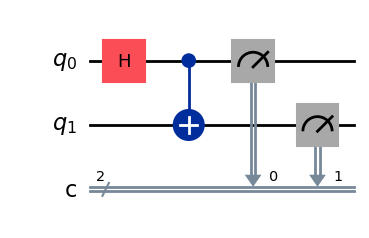

In [8]:
# 3. Create a circuit we want to run
print("\n" + "="*60)
print("Step 3: Creating Circuit")
print("="*60)
bell_circuit = QuantumCircuit(2, 2, name="bell_state")
bell_circuit.h(0)
bell_circuit.cx(0, 1)
bell_circuit.measure([0, 1], [0, 1])

print("\nOriginal Circuit:")
print(bell_circuit)
bell_circuit.draw('mpl')


Step 4: Transpiling Circuit

Transpiled Circuit (using backend's basis gates):
         ┌────────────┐     ┌─┐   
q_0 -> 1 ┤ U(π/2,0,π) ├──■──┤M├───
         └────────────┘┌─┴─┐└╥┘┌─┐
q_1 -> 2 ──────────────┤ X ├─╫─┤M├
                       └───┘ ║ └╥┘
    c: 2/════════════════════╩══╩═
                             0  1 


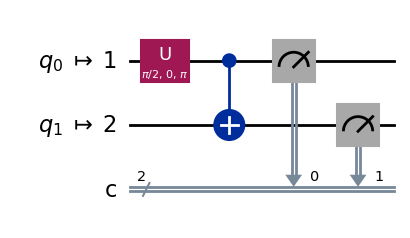

In [9]:
# 4. Transpile the circuit for our backend's target
from qiskit import transpile
# This step is crucial to ensure the circuit only uses gates our backend supports.
print("\n" + "="*60)
print("Step 4: Transpiling Circuit")
print("="*60)
transpiled_circuit = transpile(bell_circuit, backend=my_backend)
print("\nTranspiled Circuit (using backend's basis gates):")
print(transpiled_circuit)
transpiled_circuit.draw('mpl')

### Job 제출 및 상태 모니터링(Monitoring Status)

`.run()` 메서드는 `MyJob` 객체를 반환합니다. 이를 사용하여 상태를 확인하고 결과를 가져올 수 있습니다.

In [11]:
# 5. Run the transpiled circuit on our backend
print("\n" + "="*60)
print("Step 5: Running Job")
print("="*60)
job = my_backend.run(transpiled_circuit)

# 6. Check the final status
print(f"\nFinal job status: {job.status()}")
print(f"Job ID: {job.job_id()}")


Step 5: Running Job
-> Job 638b4a4a-40a4-45a6-93b5-c45684c1e0da created for circuit 'bell_state'.
-> Job 638b4a4a-40a4-45a6-93b5-c45684c1e0da is now RUNNING.
-> Job 638b4a4a-40a4-45a6-93b5-c45684c1e0da is now DONE.

Final job status: JobStatus.DONE
Job ID: 638b4a4a-40a4-45a6-93b5-c45684c1e0da


In [12]:
# 7. Get the result
print("\n" + "="*60)
print("Step 6: Retrieving Results")
print("="*60)
result = job.result()
counts = result.get_counts()
print(f"\nResulting counts: {counts}")
print(f"\nResult metadata:")
print(f"  Backend: {result.backend_name}")
print(f"  Job ID: {result.job_id}")
print(f"  Success: {result.success}")


Step 6: Retrieving Results

Resulting counts: {'00': 512, '11': 512}

Result metadata:
  Backend: my_custom_backend
  Job ID: 638b4a4a-40a4-45a6-93b5-c45684c1e0da
  Success: True



Histogram of results:


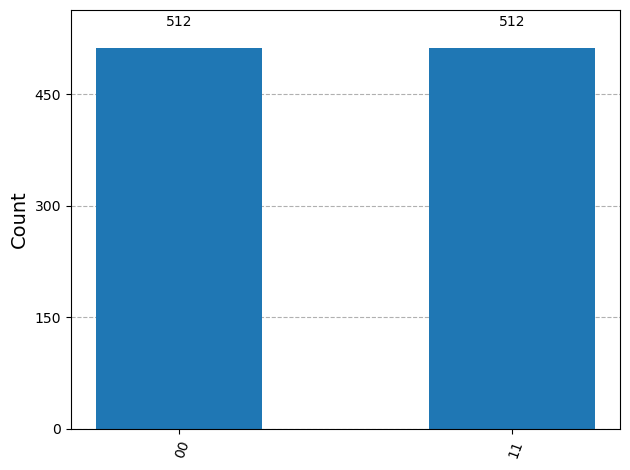

In [13]:
# 8. Plot the histogram from the result
from qiskit.visualization import plot_histogram

print("\nHistogram of results:")
plot_histogram(counts)

## Target(타겟) 이해하기

`Target` 객체는 Transpilation(트랜스파일레이션)에 매우 중요합니다. 우리 백엔드가 지원하는 연산(Operations)으로 무엇을 보고하는지 살펴보겠습니다.

In [11]:
# Get the target from our backend
target = my_backend.target

print("Backend Target Information:")
print(f"  Number of qubits: {target.num_qubits}")
print(f"\nSupported operations:")
for operation in target.operations:
    print(f"  - {operation}")

print(f"\nSupported instructions for each operation:")
for instruction_name in target.operation_names:
    qargs = target.qargs_for_operation_name(instruction_name)
    print(f"  {instruction_name}: {len(qargs)} configurations")

Backend Target Information:
  Number of qubits: 5

Supported operations:
  - Instruction(name='u', num_qubits=1, num_clbits=0, params=[Parameter(theta), Parameter(phi), Parameter(lam)])
  - Instruction(name='sx', num_qubits=1, num_clbits=0, params=[])
  - Instruction(name='cx', num_qubits=2, num_clbits=0, params=[])
  - Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])
  - Instruction(name='reset', num_qubits=1, num_clbits=0, params=[])

Supported instructions for each operation:
  u: 5 configurations
  sx: 5 configurations
  cx: 4 configurations
  measure: 5 configurations
  reset: 5 configurations


## Objective 2: JobStatus Enumeration(열거형)

`JobStatus` 열거형은 작업(Job)이 수명 주기 동안 가질 수 있는 다양한 상태를 나타냅니다. 가능한 모든 상태를 살펴보겠습니다.

In [12]:
from qiskit.providers import JobStatus

print("All possible JobStatus values:")
print("="*60)
for status in JobStatus:
    print(f"  {status.name:15} - Value: {status.value}")

print("\nTypical Job Lifecycle:")
print("  INITIALIZING → QUEUED → VALIDATING → RUNNING → DONE")
print("\nPossible terminal states:")
print("  - DONE: Job completed successfully")
print("  - ERROR: Job encountered an error")
print("  - CANCELLED: Job was cancelled by user")

All possible JobStatus values:
  INITIALIZING    - Value: job is being initialized
  QUEUED          - Value: job is queued
  VALIDATING      - Value: job is being validated
  RUNNING         - Value: job is actively running
  CANCELLED       - Value: job has been cancelled
  DONE            - Value: job has successfully run
  ERROR           - Value: job incurred error

Typical Job Lifecycle:
  INITIALIZING → QUEUED → VALIDATING → RUNNING → DONE

Possible terminal states:
  - DONE: Job completed successfully
  - ERROR: Job encountered an error
  - CANCELLED: Job was cancelled by user


## Objective 3: Sessions (Runtime 전용 개념)

**`Session`**(세션)은 여러 작업을 효율적으로 실행하기 위해 백엔드에 대한 전용 연결을 관리하는 `qiskit-ibm-runtime` 전용 개념입니다.

### 핵심 포인트(Key Points):

- 세션은 **IBM Quantum Runtime 서비스에 특화**되어 있습니다.
- 여러 작업을 위해 백엔드 시간을 예약할 수 있게 해줍니다.
- 동일한 세션 내의 후속 작업에 대한 대기 시간(Queue time)을 줄여줍니다.
- 우리가 구현한 사용자 정의 `BackendV2`는 세션을 지원하지 않습니다 (런타임 서비스가 아님).

### Session 속성(Attributes):
- `service`: QiskitRuntimeService 인스턴스
- `session_id`: 세션의 고유 식별자

### Session 메서드(Methods):
- `backend()`: 세션에 대한 백엔드를 가져옵니다.
- `cancel()`: 세션 내의 모든 작업을 취소합니다.
- `close()`: 세션을 닫습니다.
- `details()`: 세션 세부 정보를 가져옵니다.
- `from_id()`: 기존 ID에서 세션을 생성합니다.
- `status()`: 세션 상태를 가져옵니다.
- `usage()`: 리소스 사용 통계를 가져옵니다.

In [ ]:
# Example of how Sessions would be used (requires IBM Quantum account)
print("Example Session Usage (Cloud-only):")
print("="*60)
print("""
# With IBM Quantum Runtime:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2

service = QiskitRuntimeService()
backend = service.backend("ibm_brisbane")

# Create a session to run multiple jobs
with Session(service=service, backend=backend) as session:
    sampler = SamplerV2(mode=session)
    
    # Run multiple jobs within the same session
    job1 = sampler.run([circuit1])
    job2 = sampler.run([circuit2])
    job3 = sampler.run([circuit3])
    
    # Get results
    result1 = job1.result()
    result2 = job2.result()
    result3 = job3.result()
    
    # Check session info
    print(f"Session ID: {session.session_id}")
    print(f"Session status: {session.status()}")
    print(f"Session usage: {session.usage()}")

# Session automatically closes when exiting the 'with' block
""")

Example Session Usage (Cloud-only):

# With IBM Quantum Runtime:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2

service = QiskitRuntimeService()
backend = service.backend("ibm_brisbane")

# Create a session to run multiple jobs
with Session(service=service, backend=backend) as session:
    sampler = SamplerV2(session=session)

    # Run multiple jobs within the same session
    job1 = sampler.run([circuit1])
    job2 = sampler.run([circuit2])
    job3 = sampler.run([circuit3])

    # Get results
    result1 = job1.result()
    result2 = job2.result()
    result3 = job3.result()

    # Check session info
    print(f"Session ID: {session.session_id}")
    print(f"Session status: {session.status()}")
    print(f"Session usage: {session.usage()}")

# Session automatically closes when exiting the 'with' block



## 요약(Summary)

이 노트북에서 다룬 내용은 다음과 같습니다:

1. **Provider(프로바이더) 모델**:
   - 백엔드를 관리하는 사용자 정의 `Provider` 구축
   - `Target`이 정의된 사용자 정의 `BackendV2` 구현
   - 작업 수명 주기를 처리하는 사용자 정의 `Job` 클래스 생성
   - 필수적인 `_default_options()` 메서드 구현

2. **전체 Workflow(워크플로우)**:
   - 양자 회로 생성
   - 백엔드의 Basis gates(기본 게이트)에 맞춰 트랜스파일(Transpile)
   - Job을 제출하고 상태를 모니터링
   - 결과 조회 및 시각화

3. **JobStatus**: 작업 상태를 나타내는 열거형(Enumeration)에 대해 학습

4. **Sessions**: 세션이 효율적인 다중 작업 실행을 위한 Runtime(런타임) 전용 기능임을 이해

이 실습을 통해 Qiskit의 Provider 모델이 어떻게 다양한 양자 컴퓨팅 백엔드를 통합하기 위한 유연하고 확장 가능한 프레임워크를 제공하는지 확인해 보았습니다!

## 연습 문제(Practice Questions)

**1. Qiskit Provider 모델에서 백엔드의 물리적 기능(예: 지원되는 게이트, 큐비트)을 설명하는 객체는 무엇입니까?**

A) `Provider` 클래스

B) `Target` 객체 (`backend.target`)

C) `Options` 클래스

D) `Job` 클래스

***정답(Answer):***
<Details>
<br/>
B) `Target` 객체 (`backend.target`)
</Details>

---

**2. Qiskit Runtime에서 `Session`(세션)을 사용하는 주요 이점은 무엇입니까?**

A) 인터넷 연결 없이 오프라인으로 작업을 실행할 수 있게 해준다

B) 결과에 오류가 없음을 보장한다

C) 대기 시간(Queuing delay)을 줄여 여러 작업을 효율적으로 실행할 수 있게 해준다

D) 백엔드에서 사용 가능한 큐비트 수를 늘려준다

***정답(Answer):***
<Details>
<br/>
C) 대기 시간(Queuing delay)을 줄여 여러 작업을 효율적으로 실행할 수 있게 해준다
</Details>

---

**3. 작업(Job)이 성공적으로 완료되었음을 나타내는 `JobStatus`는 무엇입니까?**

A) `JobStatus.RUNNING`

B) `JobStatus.QUEUED`

C) `JobStatus.DONE`

D) `JobStatus.VALIDATING`

***정답(Answer):***
<Details>
<br/>
C) `JobStatus.DONE`
</Details>